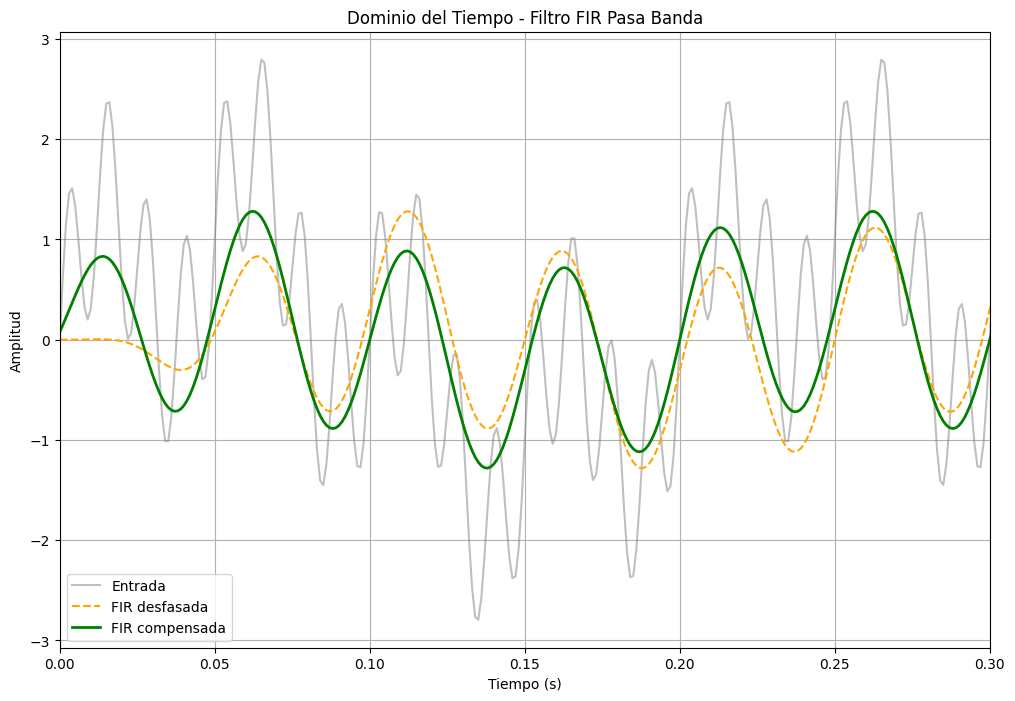

In [14]:
!pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
from scipy.fft import fft, fftfreq

fs = 1000
t = np.arange(0, 1.0, 1/fs)

# Frecuencias de la señal
f1, f2, f3 = 5, 20, 80

# Señal de entrada
x = (
    np.sin(2 * np.pi * f1 * t) +
    np.sin(2 * np.pi * f2 * t) +
    np.sin(2 * np.pi * f3 * t)
)

# Diseño del filtro FIR pasa banda
N = 101
f_baja = 10.0
f_alta = 30.0

fir = firwin(
    numtaps=N,
    cutoff=[f_baja, f_alta],
    pass_zero=False,
    fs=fs
)
# Filtrado
x_f = lfilter(fir, 1.0, x)

# Compensación del retardo del filtro FIR
delay = (N - 1) // 2
x_ff = np.append(x_f[delay:], np.zeros(delay))

# Vector de frecuencias
n = len(t)
frecuencias = fftfreq(n, 1/fs)[:n//2]

plt.figure(figsize=(12, 8))

plt.plot(t, x, label='Entrada', color='gray', alpha=0.5)
plt.plot(t, x_f, label='FIR desfasada', color='orange', linestyle='--')
plt.plot(t, x_ff, label='FIR compensada', color='green', linewidth=2)

plt.title('Dominio del Tiempo - Filtro FIR Pasa Banda')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.xlim(0, 0.3)
plt.grid(True)
plt.legend()
plt.show()

In [6]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.4 MB/s eta 0:00:00


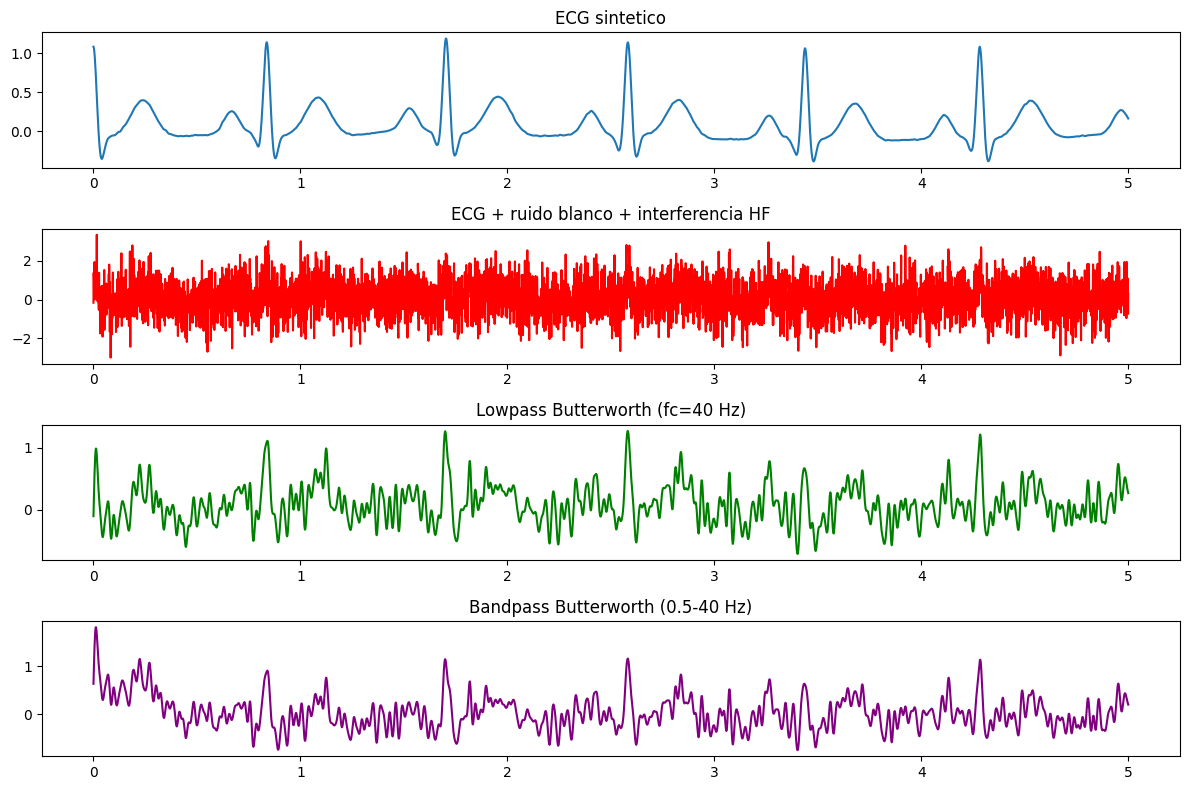

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import butter, filtfilt

fs = 1000
t = np.arange(0, 5, 1/fs)

# Aplicamos el ECG sintetico con NeuroKit2
ecg = nk.ecg_simulate(duration=5, sampling_rate=fs, heart_rate=70)

# Empleamos el ruido blanco junto la interferencia de alta frecuencia
np.random.seed(50)
r = 0.8 * np.random.randn(len(t))
h    = 0.4 * np.sin(2*np.pi*150*t)
noisy = ecg + r + h

# Filtros Butterworth
b_1, a_1 = butter(4, 40, btype='low', fs=fs)
ecg_bajo = filtfilt(b_1, a_1, noisy)

b_2, a_2 = butter(4, [0.5, 40], btype='bandpass', fs=fs)
ecg_banda = filtfilt(b_2, a_2, noisy)

# Ahora ploteamos los gráficos
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, ecg)
plt.title('ECG sintetico')

plt.subplot(4, 1, 2)
plt.plot(t, noisy, color='red')
plt.title('ECG + ruido blanco + interferencia HF')

plt.subplot(4, 1, 3)
plt.plot(t, ecg_bajo, color='green')
plt.title('Lowpass Butterworth (fc=40 Hz)')

plt.subplot(4, 1, 4)
plt.plot(t, ecg_banda, color='purple')
plt.title('Bandpass Butterworth (0.5-40 Hz)')

plt.tight_layout()
plt.show()

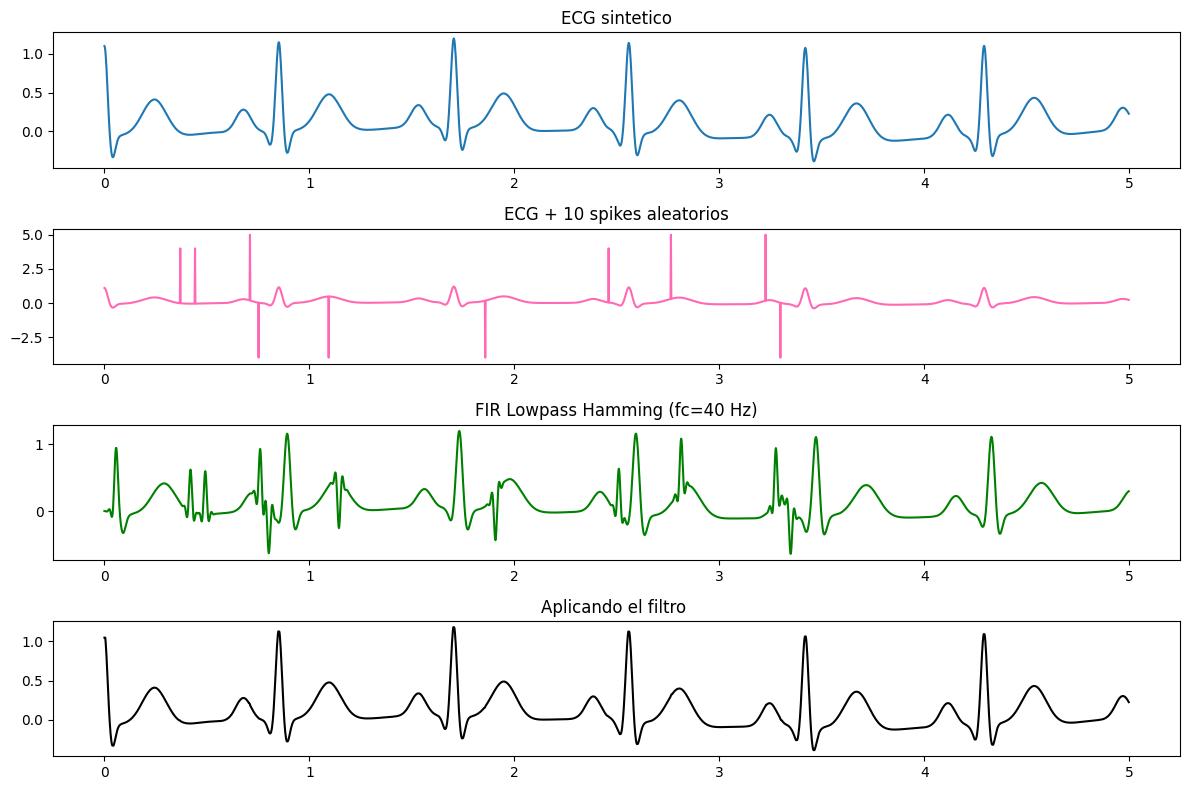

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import firwin, lfilter, medfilt

fs = 500
t = np.arange(0, 5, 1/fs)

# ECG sintetico
ecg = nk.ecg_simulate(duration=5, sampling_rate=fs, heart_rate=70)


np.random.seed(7)
ecg_ruido = ecg.copy()
idx = np.random.randint(10, len(t)-10, size=10)
for i in idx:
    ecg_ruido[i] = np.random.choice([-4, -3, 4, 5])

# FIR lowpass con ventana Hamming
# frecuencia de corte 40 Hz
b_fir = firwin(51, 40, window='hamming', fs=fs)
ecg_fir = lfilter(b_fir, 1.0, ecg_noisy)

# Filtro mediana: reemplaza cada muestra por la mediana de sus vecinos
ecg_filtro = medfilt(ecg_ruido, kernel_size=5)

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, ecg)
plt.title('ECG sintetico')

plt.subplot(4, 1, 2)
plt.plot(t, ecg_ruido, color='hotpink')
plt.title('ECG + 10 spikes aleatorios')

plt.subplot(4, 1, 3)
plt.plot(t, ecg_fir, color='green')
plt.title('FIR Lowpass Hamming (fc=40 Hz)')

plt.subplot(4, 1, 4)
plt.plot(t, ecg_filtro, color='black')
plt.title('Aplicando el filtro ')

plt.tight_layout()
plt.show()

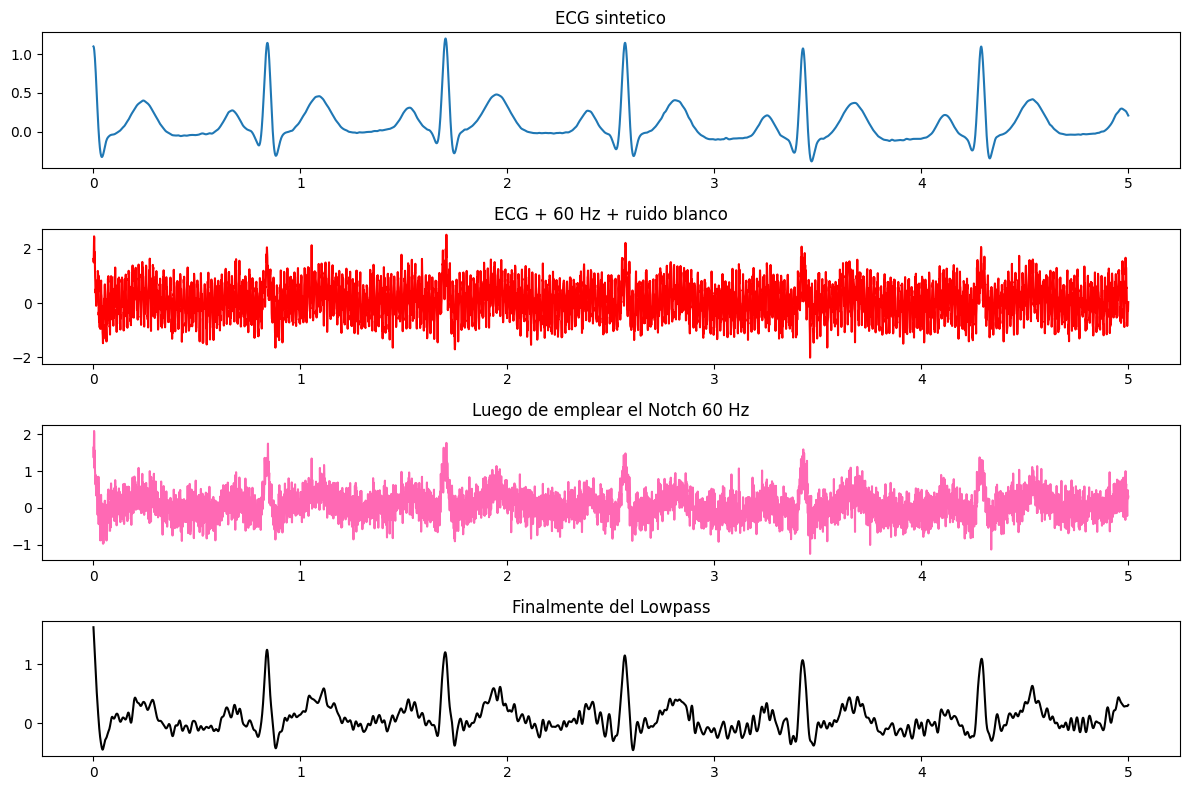

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import iirnotch, butter, filtfilt
# Un monitor ECG hospitalario presenta interferencia
# causada por la red eléctrica.
fs = 1000
t = np.arange(0, 5, 1/fs)

# ECG sintetico
ecg = nk.ecg_simulate(duration=5, sampling_rate=fs, heart_rate=70)

# Ruido 60 Hz + blanco
np.random.seed(0)
r_60 = 0.8 * np.sin(2*np.pi*60*t)
r    = 0.3 * np.random.randn(len(t))
noisy    = ecg + r_60 + r

# Notch 60 Hz
b_1, a_1 = iirnotch(60, 30, fs)
ecg_notch = filtfilt(b_1, a_1, noisy)

# Lowpass para ruido residual
b_2, a_2 = butter(4, 40, btype='low', fs=fs)
ecg_total = filtfilt(b_2, a_2, ecg_notch)

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, ecg)
plt.title('ECG sintetico')

plt.subplot(4, 1, 2)
plt.plot(t, noisy, color='red')
plt.title('ECG + 60 Hz + ruido blanco')

plt.subplot(4, 1, 3)
plt.plot(t, ecg_notch,  color='hotpink')
plt.title('Luego de emplear el Notch 60 Hz')

plt.subplot(4, 1, 4)
plt.plot(t, ecg_total, color='black')
plt.title('Finalmente del Lowpass')

plt.tight_layout()
plt.show()

Delay estimado sobre la respiración: 9029 muestras
Delay estimado sobre el acelerómetro:  1510 muestras


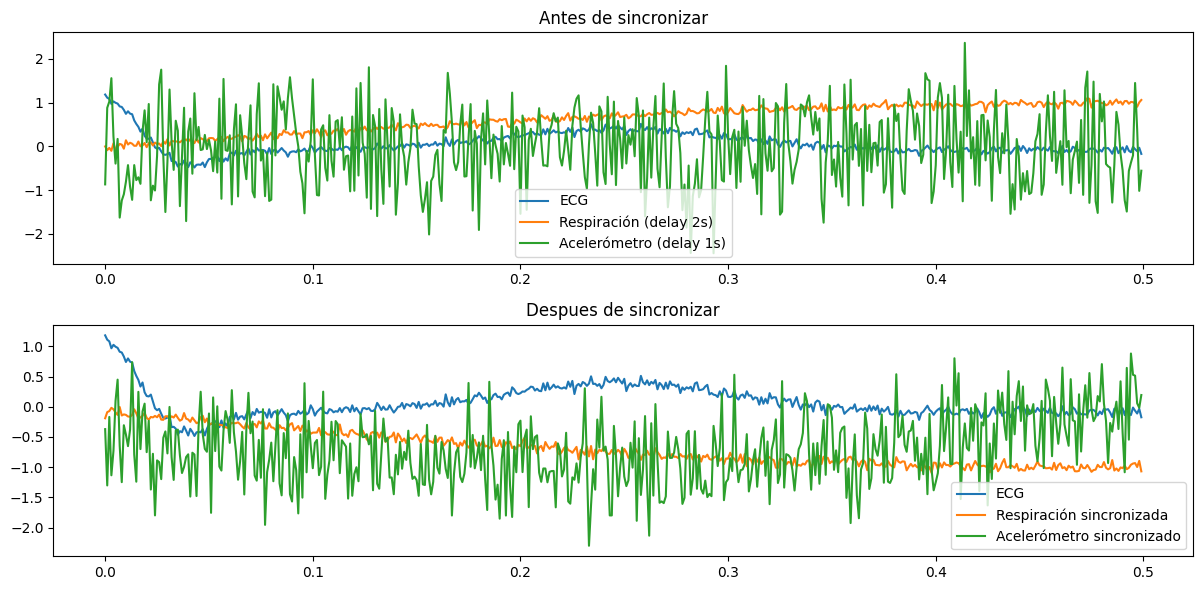

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import correlate

# Cada sensor inicia adquisición en tiempos distintos.
fs = 1000
dur = 10

ecg = nk.ecg_simulate(duration=dur, sampling_rate=fs, heart_rate=70)

t = np.arange(0, dur, 1/fs)
resp = np.sin(2*np.pi*0.5*t)
acelerometro  = np.sin(2*np.pi**t)

# Aplicar delays de 2s
np.random.seed(3)
delay_respiracion = int(2.0*fs)
delay_acelerometro = int(1.0*fs)

s_ecg  = ecg  + 0.05*np.random.randn(len(t))
s_respiracion = np.roll(resp, delay_respiracion) + 0.05*np.random.randn(len(t))
s_acelerometro  = np.roll(acelerometro,  delay_acelerometro)  + 0.5*np.random.randn(len(t))

# Estimar delay con correlacion cruzada
corr_respiracion = correlate(s_ecg, s_respiracion)
corr_acelerometro  = correlate(s_ecg, s_acelerometro)

delay_est_respiracion = np.argmax(corr_respiracion) - len(s_ecg) + 1
delay_est_acelerometro = np.argmax(corr_acelerometro)  - len(s_ecg) + 1

print("Delay estimado sobre la respiración:", delay_est_respiracion, "muestras")
print("Delay estimado sobre el acelerómetro: ", delay_est_acelerometro,  "muestras")

resp_sincronizado = np.roll(s_respiracion, -delay_est_respiracion)
acc_sincronizado  = np.roll(s_acelerometro,  -delay_est_acelerometro)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:500], s_ecg[:500],  label='ECG')
plt.plot(t[:500], s_respiracion [:500], label='Respiración (delay 2s)')
plt.plot(t[:500], s_acelerometro[:500],  label='Acelerómetro (delay 1s)')
plt.title('Antes de sincronizar')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t[:500], s_ecg[:500],    label='ECG')
plt.plot(t[:500], resp_sincronizado[:500], label='Respiración sincronizada')
plt.plot(t[:500], acc_sincronizado[:500],  label='Acelerómetro sincronizado')
plt.title('Despues de sincronizar')
plt.legend()

plt.tight_layout()
plt.show()


ECG:  5000 muestras @ 1000 Hz
Respiracion original:  500 muestras @ 100 Hz
Respiracion resampleo:  5000 muestras @ 1000 Hz
Acelerometro original:   1000 muestras @ 200 Hz
Acelerometro resampleo:   5000 muestras @ 1000 Hz


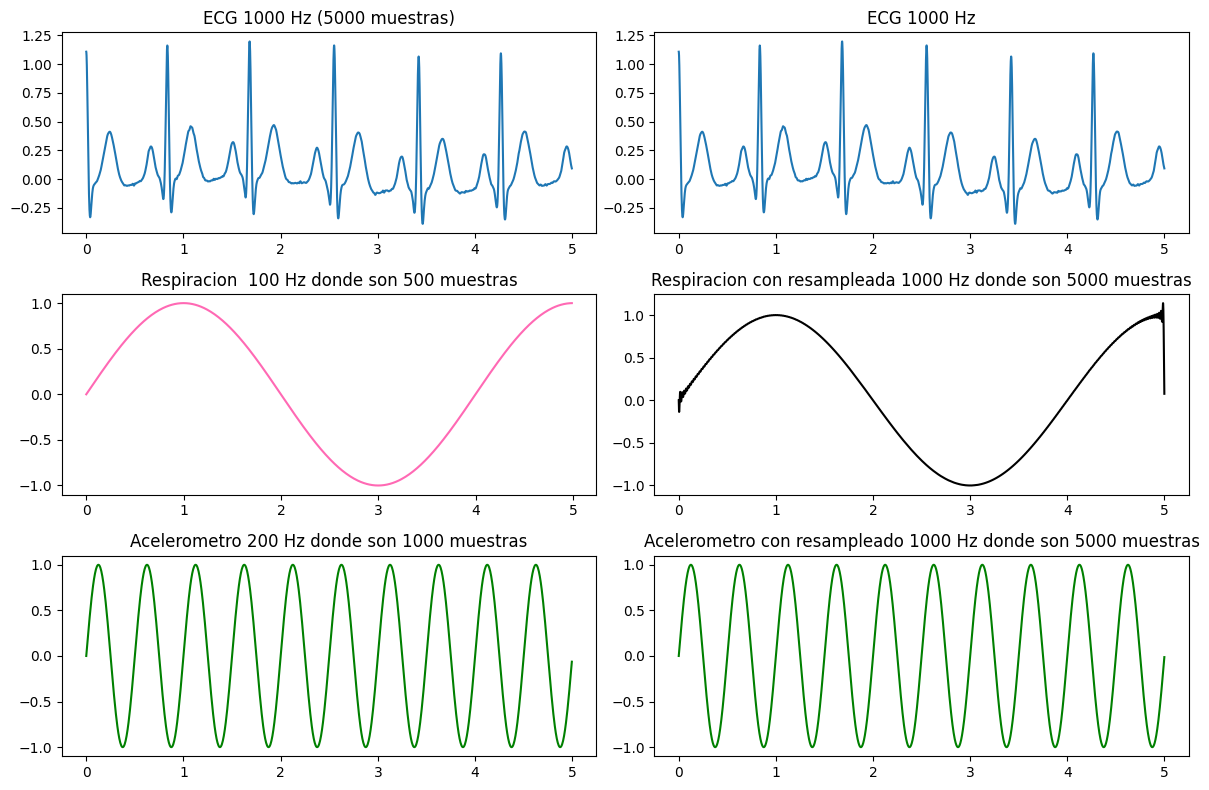

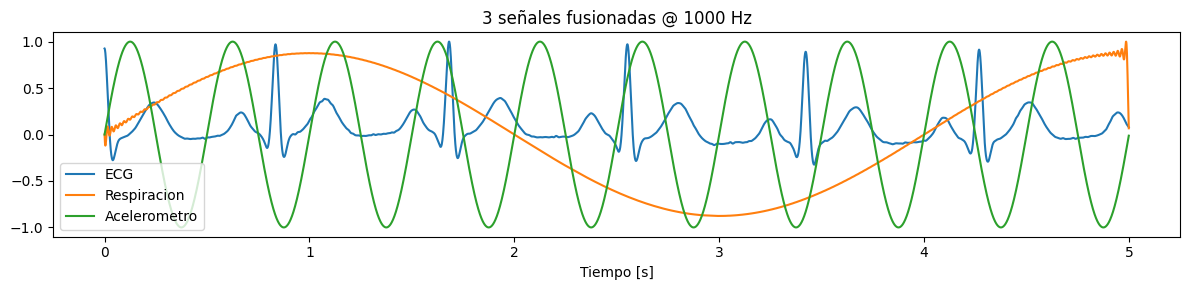

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import resample

fs_ecg  = 1000
fs_respiracion = 100
fs_acelerometro  = 200
dur = 5

t_ecg  = np.arange(0, dur, 1/fs_ecg)
t_respiracion = np.arange(0, dur, 1/fs_respiracion)
t_acelerometro  = np.arange(0, dur, 1/fs_acelerometro)


ecg = nk.ecg_simulate(duration=dur, sampling_rate=fs_ecg, heart_rate=70)

respiracion = np.sin(2*np.pi*0.25*t_respiracion)
acelerometro = np.sin(2*np.pi*2.0*t_acelerometro)

respiracion_res = resample(respiracion, len(t_ecg))
acelerometro_res  = resample(acelerometro,  len(t_ecg))

print("ECG: ", len(ecg),      "muestras @", fs_ecg,  "Hz")
print("Respiracion original: ", len(respiracion),     "muestras @", fs_respiracion, "Hz")
print("Respiracion resampleo: ", len(respiracion_res), "muestras @", fs_ecg,  "Hz")
print("Acelerometro original:  ", len(acelerometro),      "muestras @", fs_acelerometro,  "Hz")
print("Acelerometro resampleo:  ", len(acelerometro_res),  "muestras @", fs_ecg,  "Hz")

plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.plot(t_ecg, ecg)
plt.title(f'ECG {fs_ecg} Hz ({len(ecg)} muestras)')

plt.subplot(3, 2, 3)
plt.plot(t_respiracion, respiracion, color='hotpink')
plt.title(f'Respiracion  {fs_respiracion} Hz donde son {len(respiracion)} muestras')

plt.subplot(3, 2, 5)
plt.plot(t_acelerometro, acelerometro, color='green')
plt.title(f'Acelerometro {fs_acelerometro} Hz donde son {len(acelerometro)} muestras')

plt.subplot(3, 2, 2)
plt.plot(t_ecg, ecg)
plt.title(f'ECG {fs_ecg} Hz')

plt.subplot(3, 2, 4)
plt.plot(t_ecg, respiracion_res, color='black')
plt.title(f'Respiracion con resampleada {fs_ecg} Hz donde son {len(respiracion_res)} muestras')

plt.subplot(3, 2, 6)
plt.plot(t_ecg, acelerometro_res, color='green')
plt.title(f'Acelerometro con resampleado {fs_ecg} Hz donde son {len(acelerometro_res)} muestras')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t_ecg, ecg/np.max(np.abs(ecg)),           label='ECG')
plt.plot(t_ecg, respiracion_res/np.max(np.abs(respiracion_res)),  label='Respiracion')
plt.plot(t_ecg, acelerometro_res/np.max(np.abs(acelerometro_res)),    label='Acelerometro')
plt.title('3 señales fusionadas @ 1000 Hz')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.tight_layout()
plt.show()